## Setup

In [1]:
from pathlib import Path
import importlib
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import shells
from common import visualize
import mfgp

SHELL_CONFIG = Path("../configs/shell.toml").resolve()
CNP_CONFIG = Path("../configs/cnp.toml").resolve()
MFGP_CONFIG = Path("../configs/mfgp.toml").resolve()

print(f"Shell config: {SHELL_CONFIG}")
print(f"CNP config:   {CNP_CONFIG}")
print(f"MFGP config:  {MFGP_CONFIG}")

Shell config: /home/pknauss/XLZD/configs/shell.toml
CNP config:   /home/pknauss/XLZD/configs/cnp.toml
MFGP config:  /home/pknauss/XLZD/configs/mfgp.toml


## Prepare shell data

This uses the shell TOML to create the prepared LF/HF training blocks and held-out HF validation blocks.

Skip this cell when the prepared HDF5 data already exists and you do not want to rebuild it.

In [2]:
%%time
shell_config = shells.build_config(SHELL_CONFIG)
prepare_result = shells.prepare_shell_cnp_data(shell_config)
prepare_result


[22:52:41] Clearing existing dataset directory: ../outputs/shell
[done in 0.10s] Removed previous shell dataset

[22:52:41] Loading file manifest
[done in 0.00s] Loaded 205 manifest rows from ../data/train_data/file_manifest.csv

Processing manifest row 1
source_file=R1716_H352_F0_2447keVgamma_withcuts.csv
manifest R=1716.0, Z=352.0
fidelity=0

[22:52:41] Loading R1716_H352_F0_2447keVgamma_withcuts.csv
[done in 0.00s] Loaded 2,032 rows

[22:52:41] Using detector geometry and fidelity from manifest
[done in 0.00s] Using manifest values: fidelity=0, z_center=352, R=1716, Z=352

[22:52:41] Building shell table and assigning target shells
[warn] Some shell classes have low support, but they are kept for categorical CE because class IDs must remain fixed
[done in 0.01s] Assigned shells for 2,032/2,032 events

Processing manifest row 2
source_file=R113_H1663_F0_2447keVgamma_withcuts.csv
manifest R=113.0, Z=1663.0
fidelity=0

[22:52:41] Loading R113_H1663_F0_2447keVgamma_withcuts.csv
[done i

PreparationResult(output_dir=PosixPath('../outputs/shell'), training_dir=PosixPath('../outputs/shell/training'), validation_dir=PosixPath('../outputs/shell/validation'), shell_table_path=PosixPath('../outputs/shell/shell_table_by_theta.csv'), manifest_path=PosixPath('../outputs/shell/event_class_manifest.csv'))

## Train CNP

/home/pknauss/xlzd/lib/python3.14/site-packages/torch/cuda/__init__.py:188: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12090). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /__w/pytorch/pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


Epoch 1/15:   0%|          | 0/100 [00:00<?, ?Batch/s]

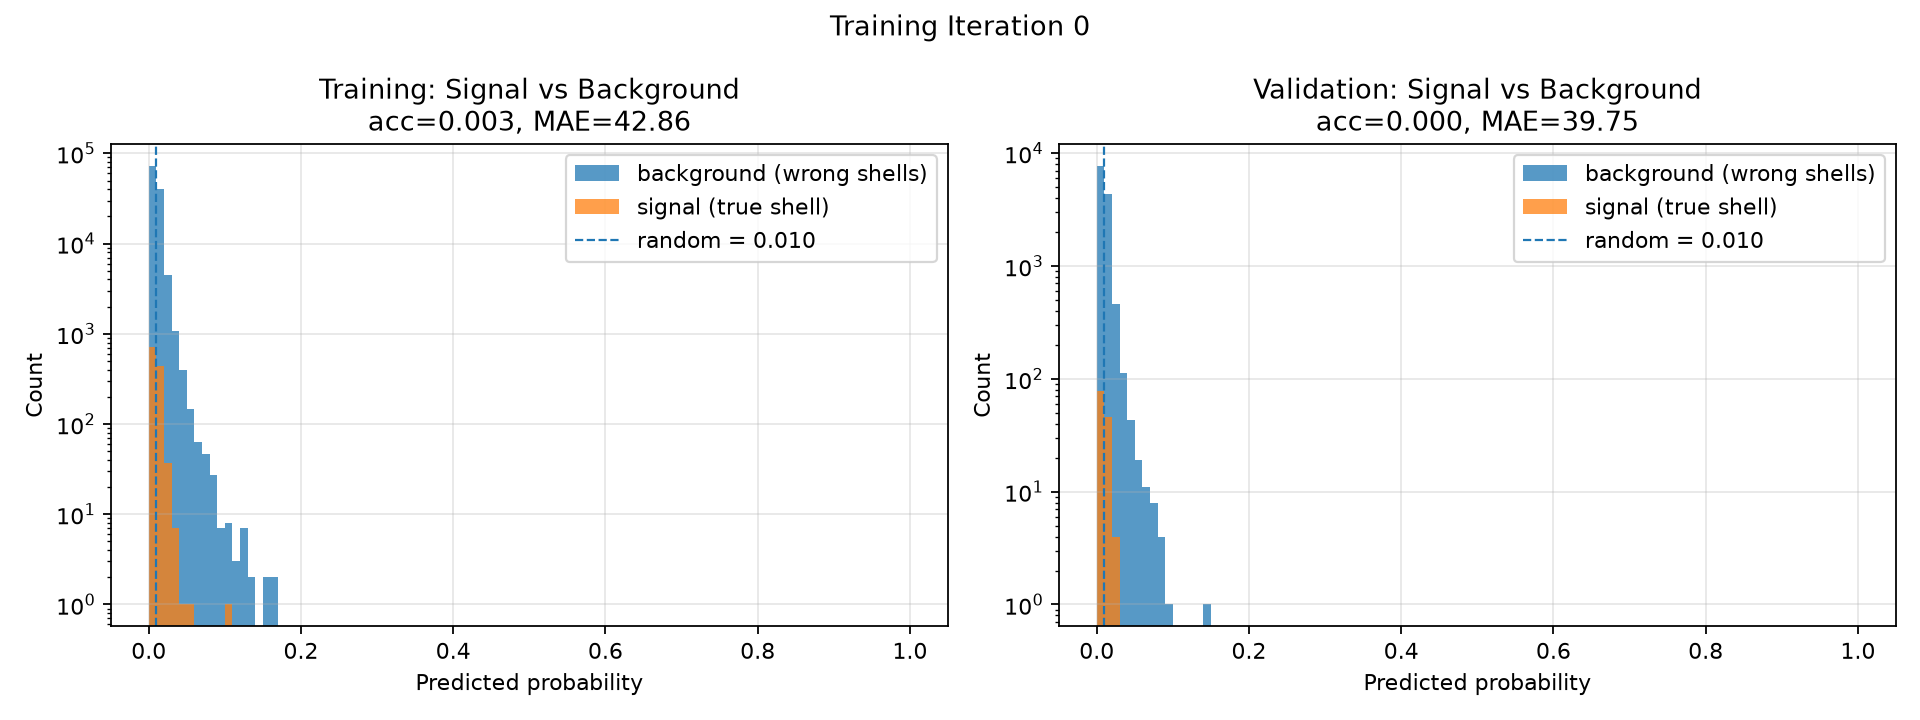

Epoch 2/15:   0%|          | 0/100 [00:00<?, ?Batch/s]

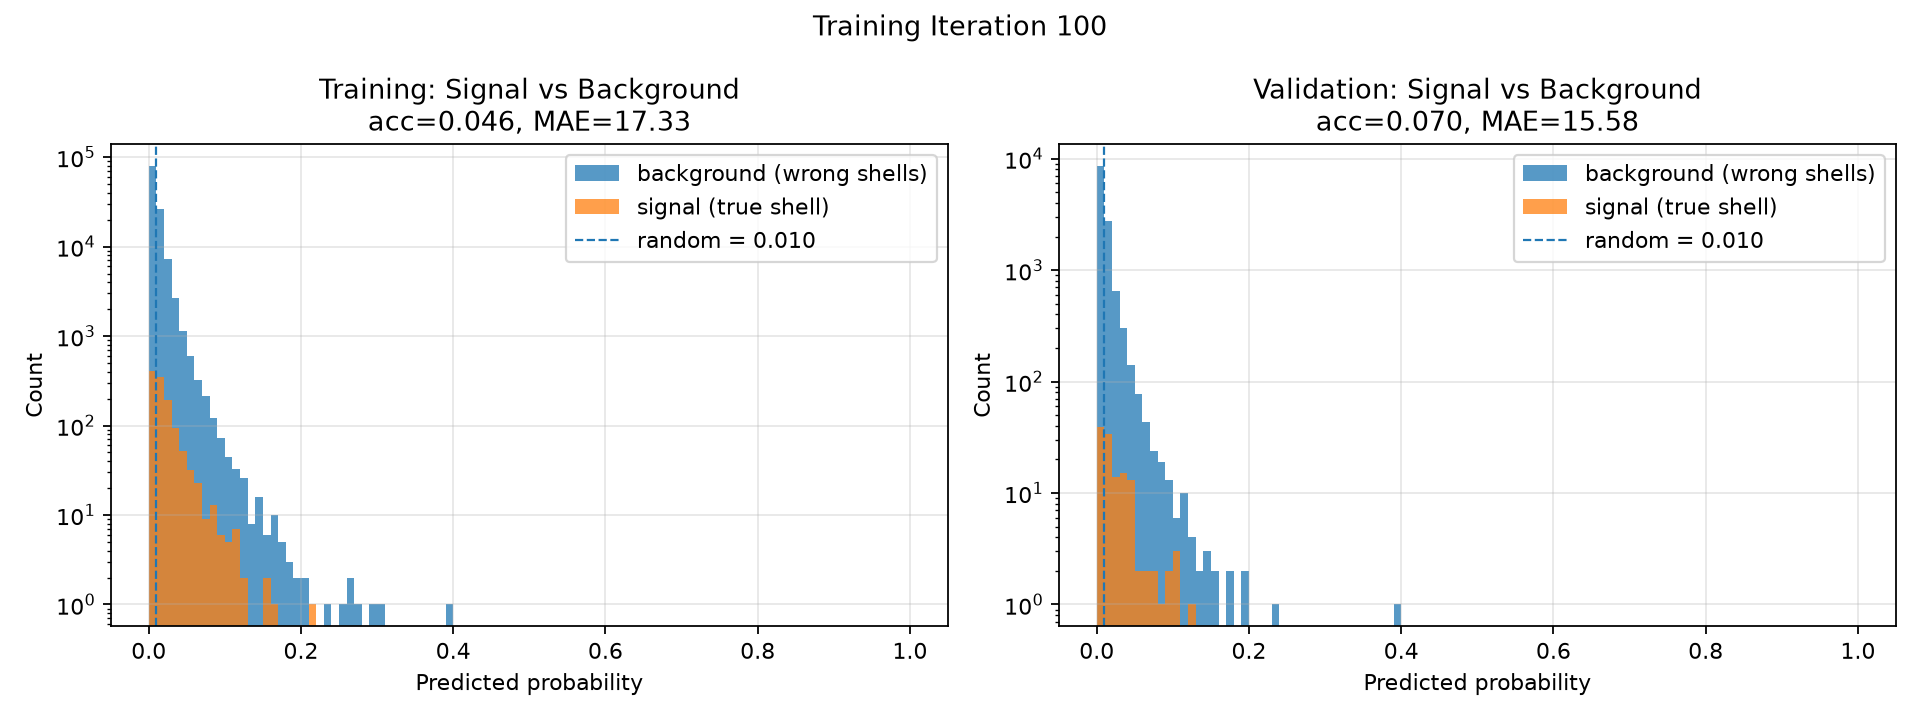

Epoch 3/15:   0%|          | 0/100 [00:00<?, ?Batch/s]

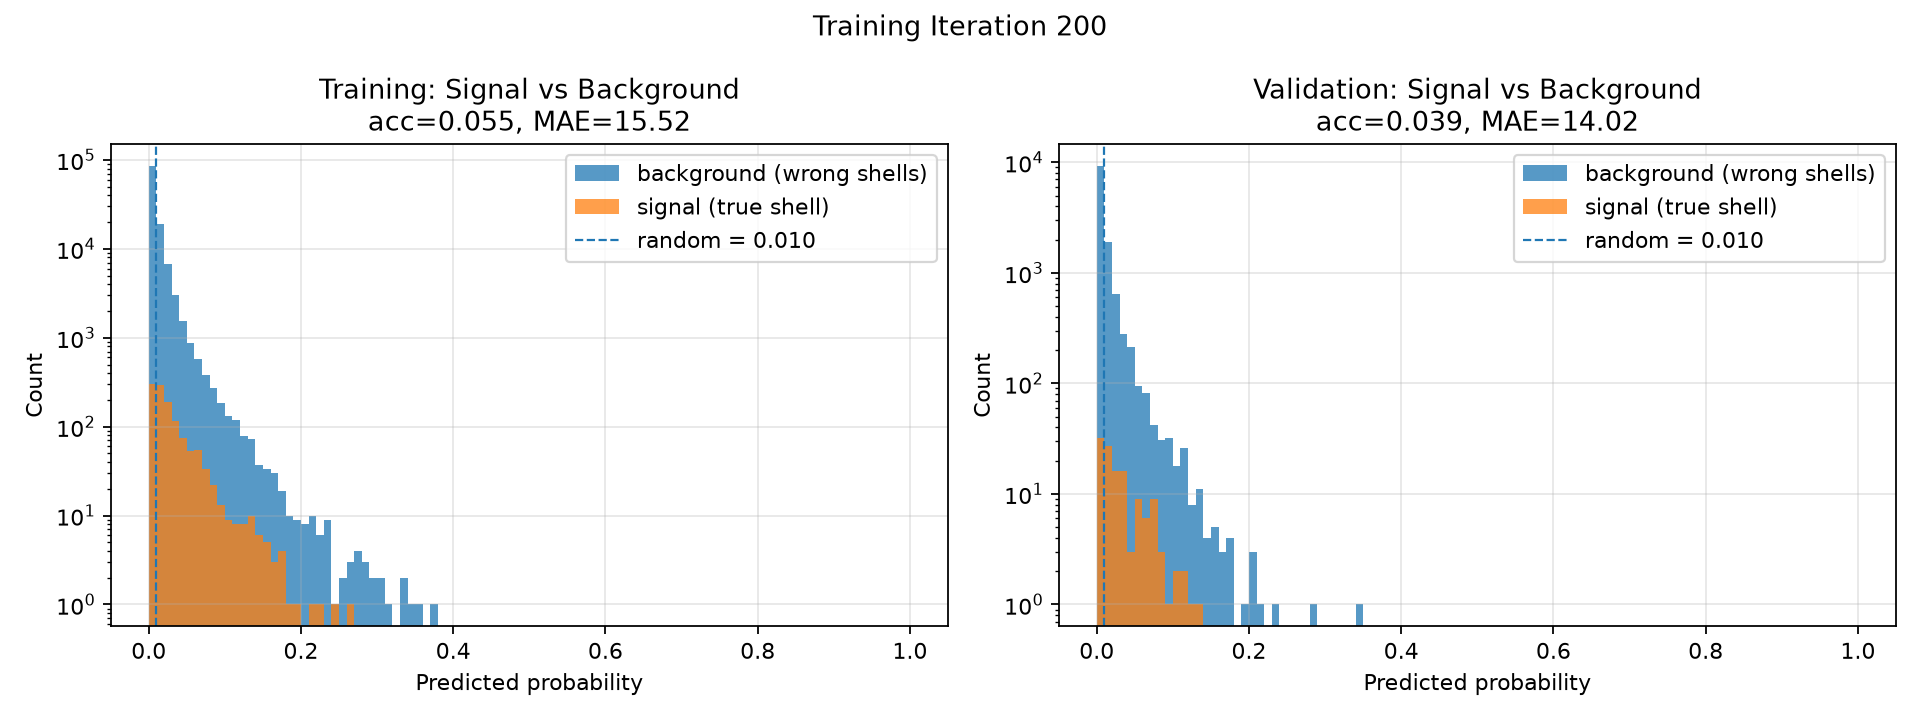

Epoch 4/15:   0%|          | 0/100 [00:00<?, ?Batch/s]

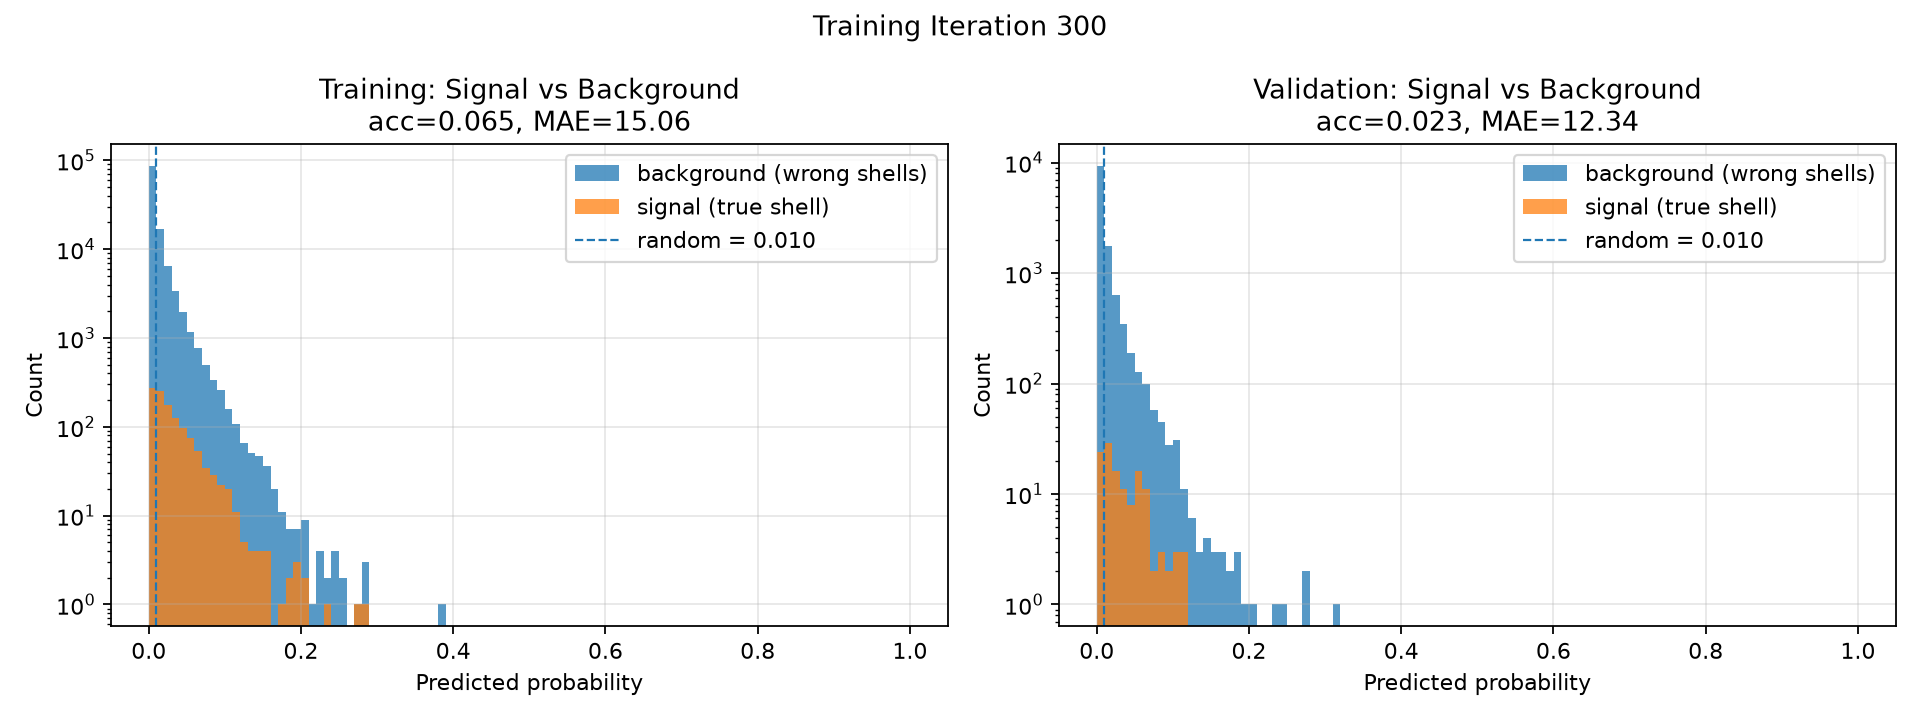

Epoch 5/15:   0%|          | 0/100 [00:00<?, ?Batch/s]

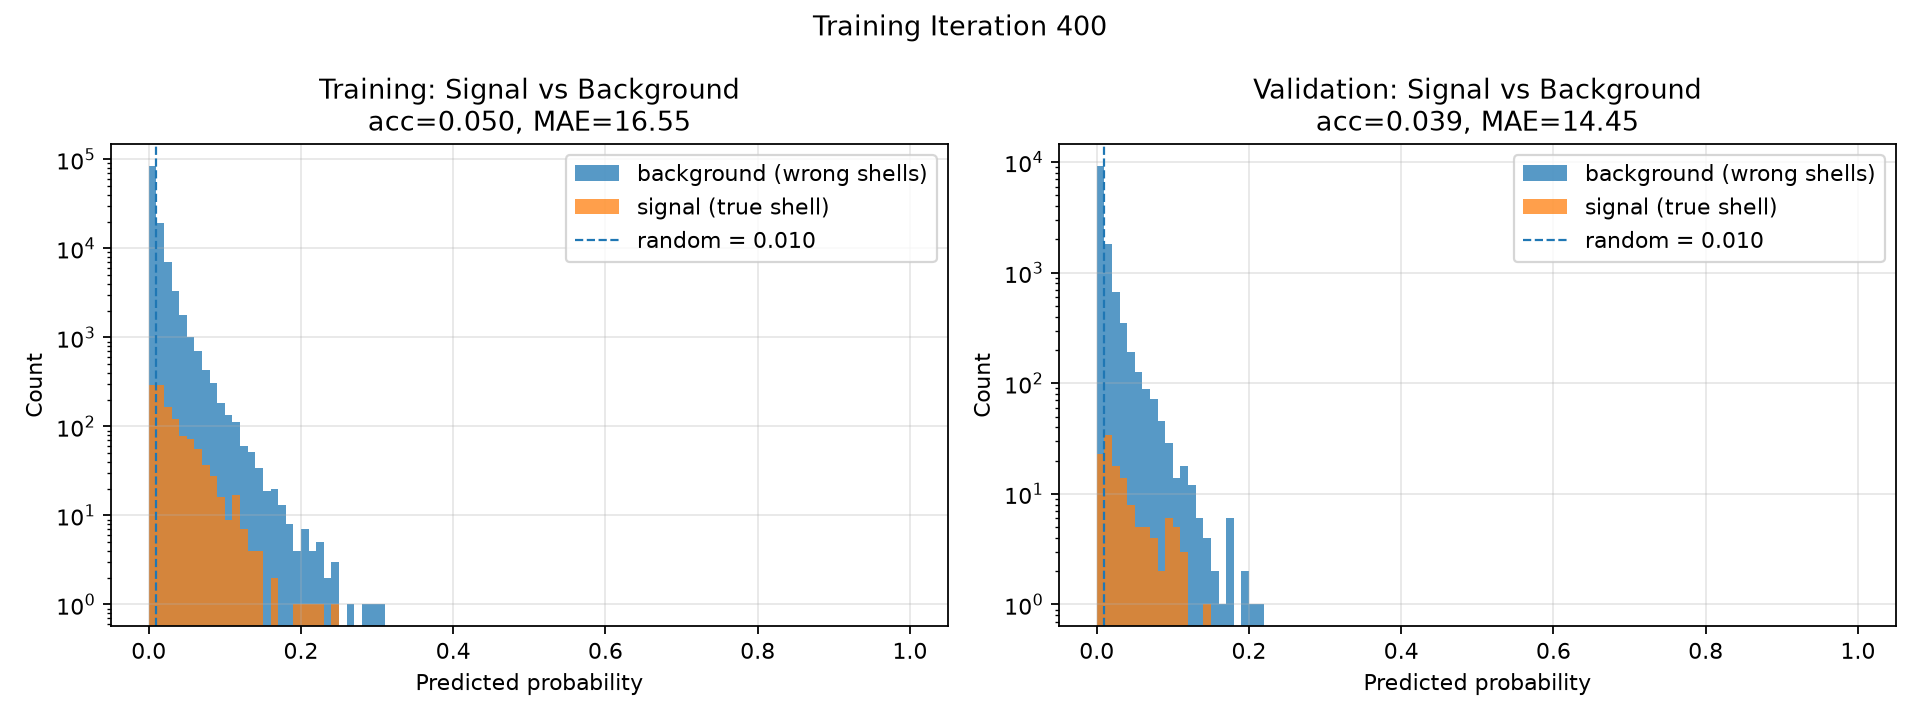

Epoch 6/15:   0%|          | 0/100 [00:00<?, ?Batch/s]

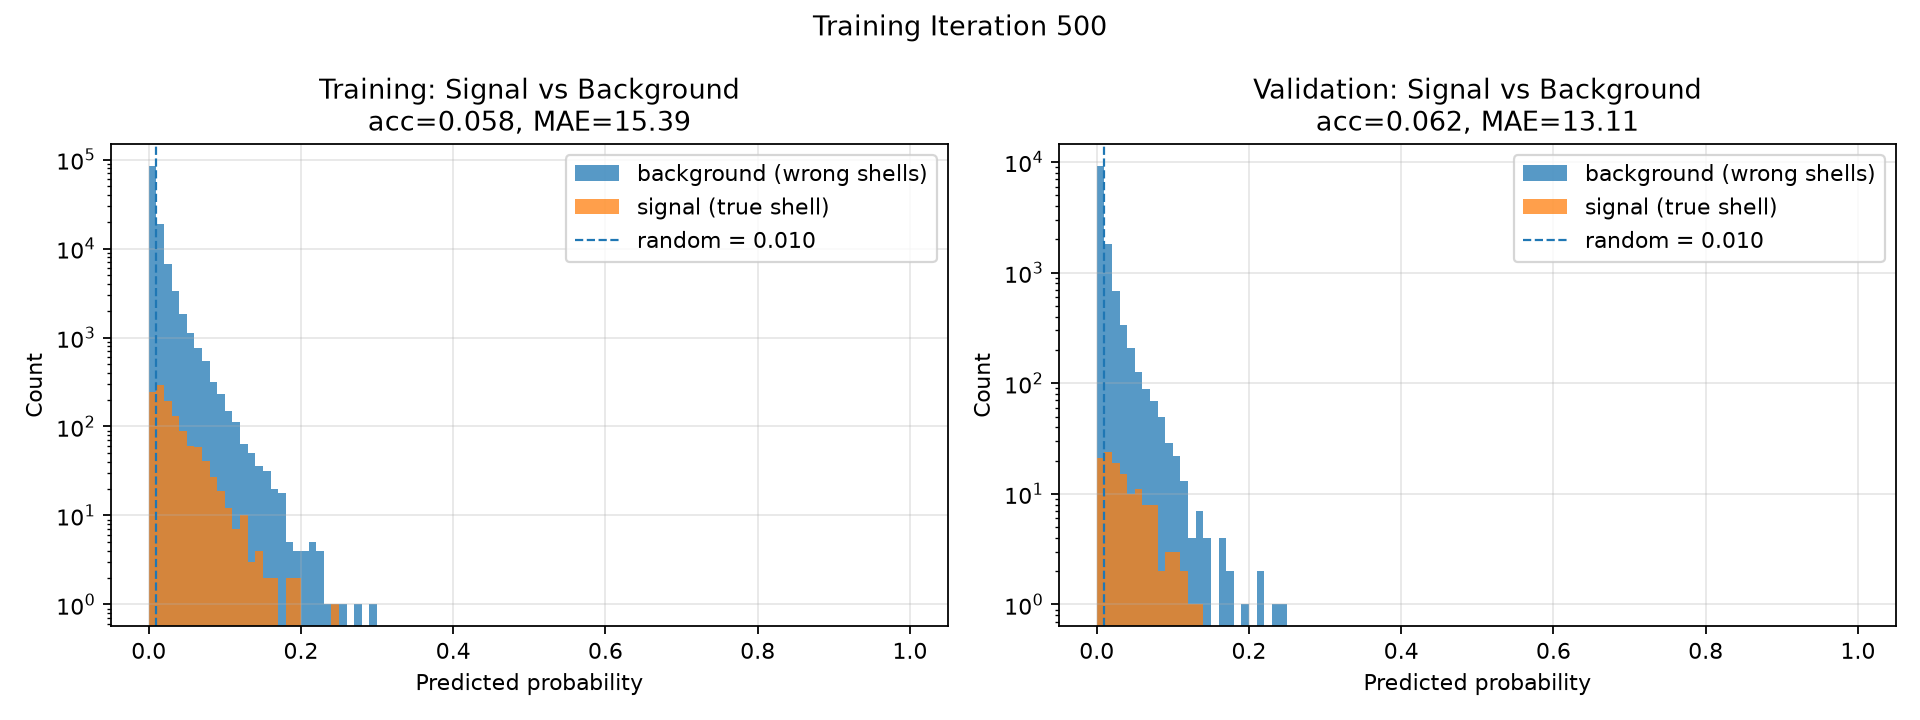

Epoch 7/15:   0%|          | 0/100 [00:00<?, ?Batch/s]

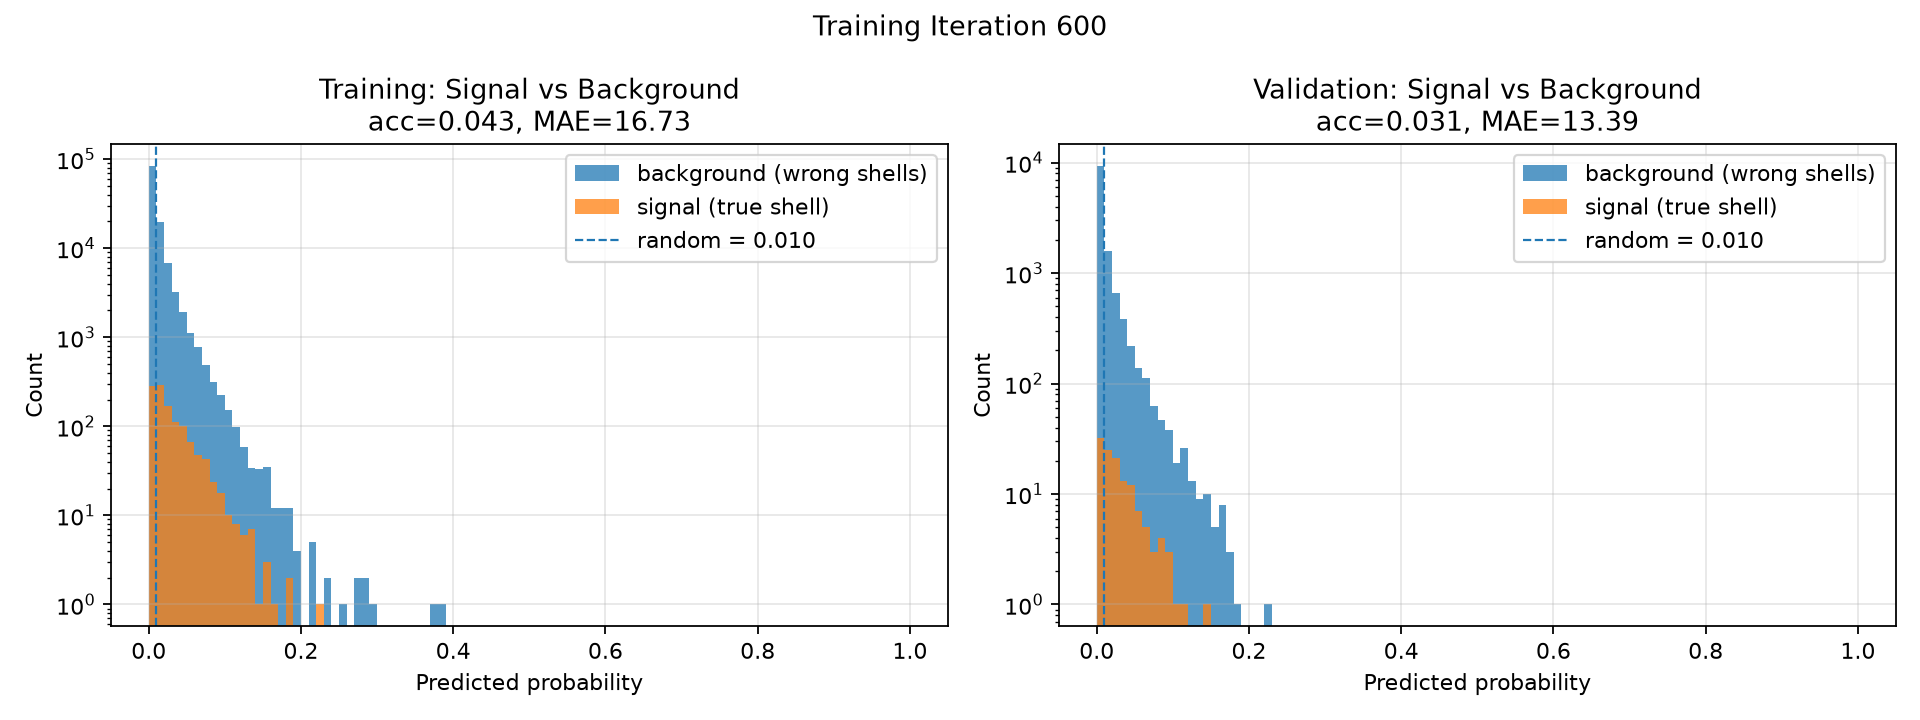

Epoch 8/15:   0%|          | 0/100 [00:00<?, ?Batch/s]

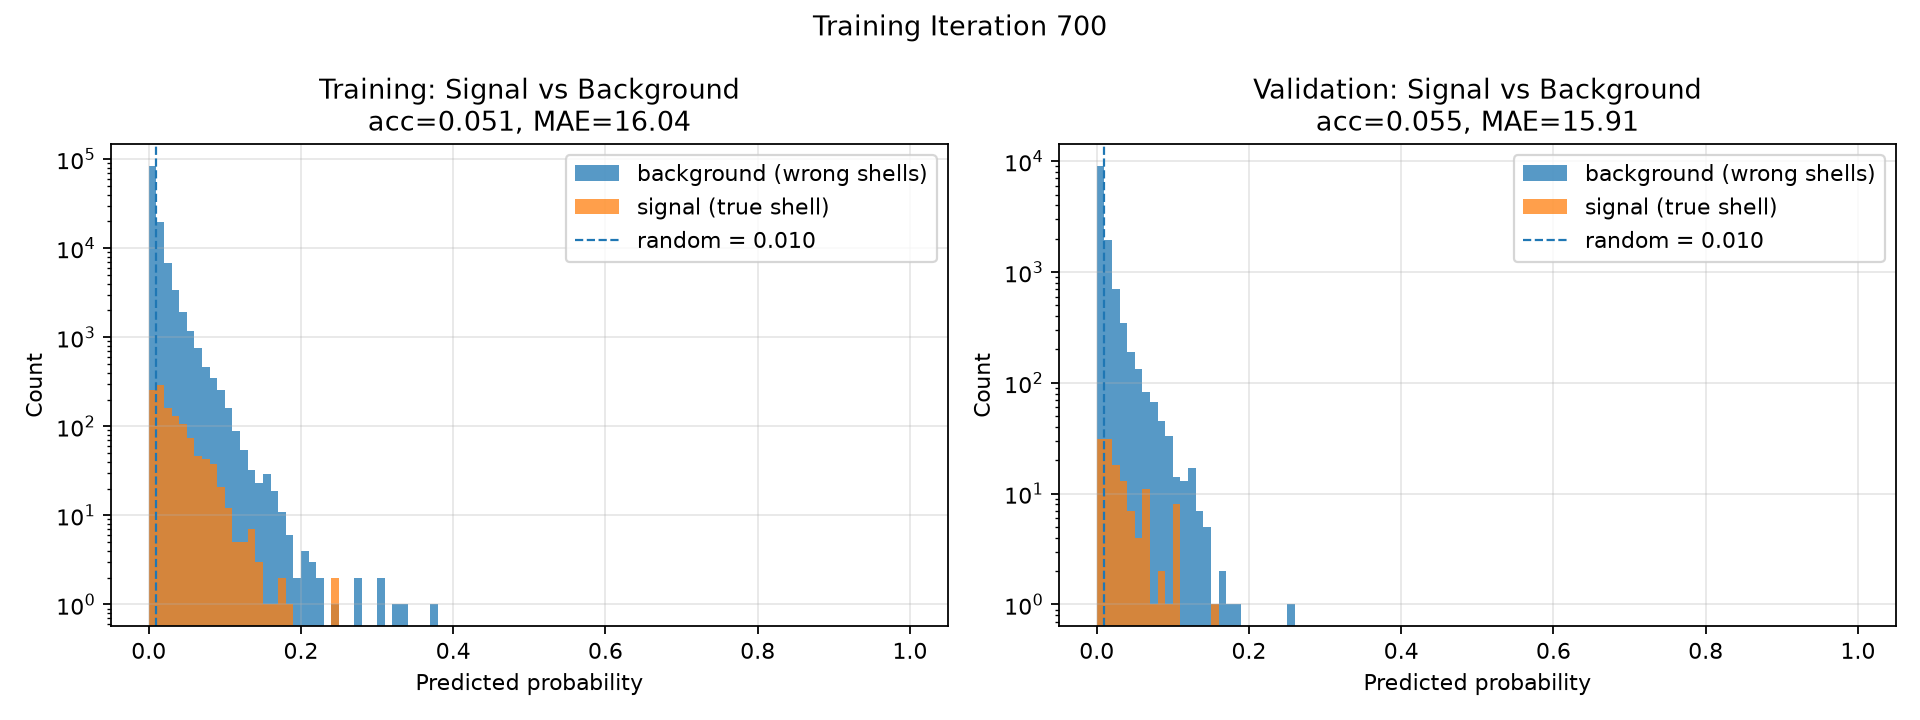

Epoch 9/15:   0%|          | 0/100 [00:00<?, ?Batch/s]

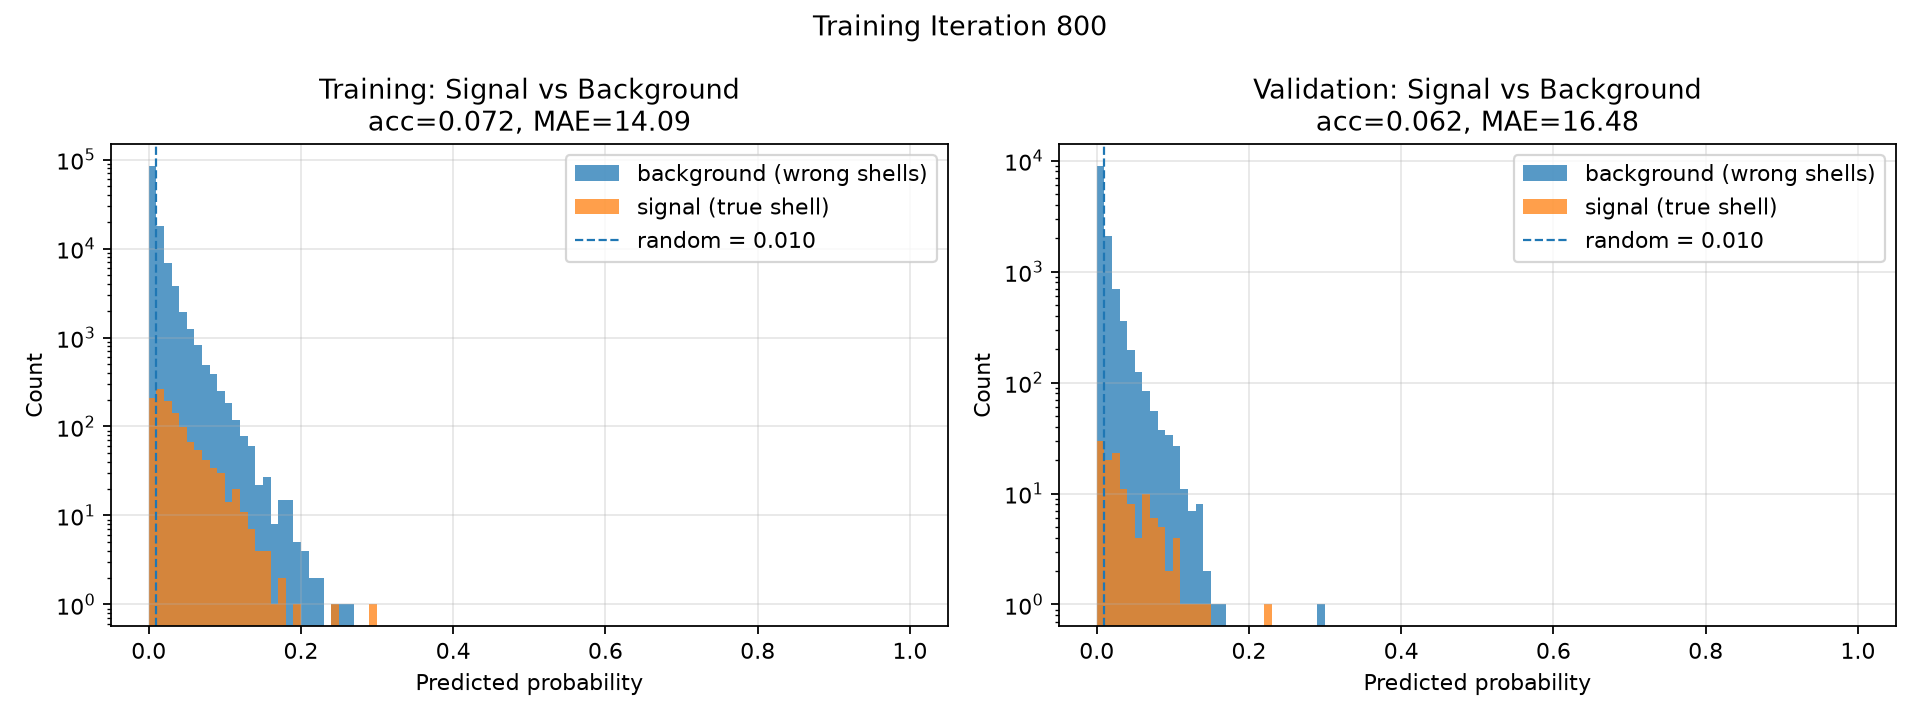

Epoch 10/15:   0%|          | 0/100 [00:00<?, ?Batch/s]

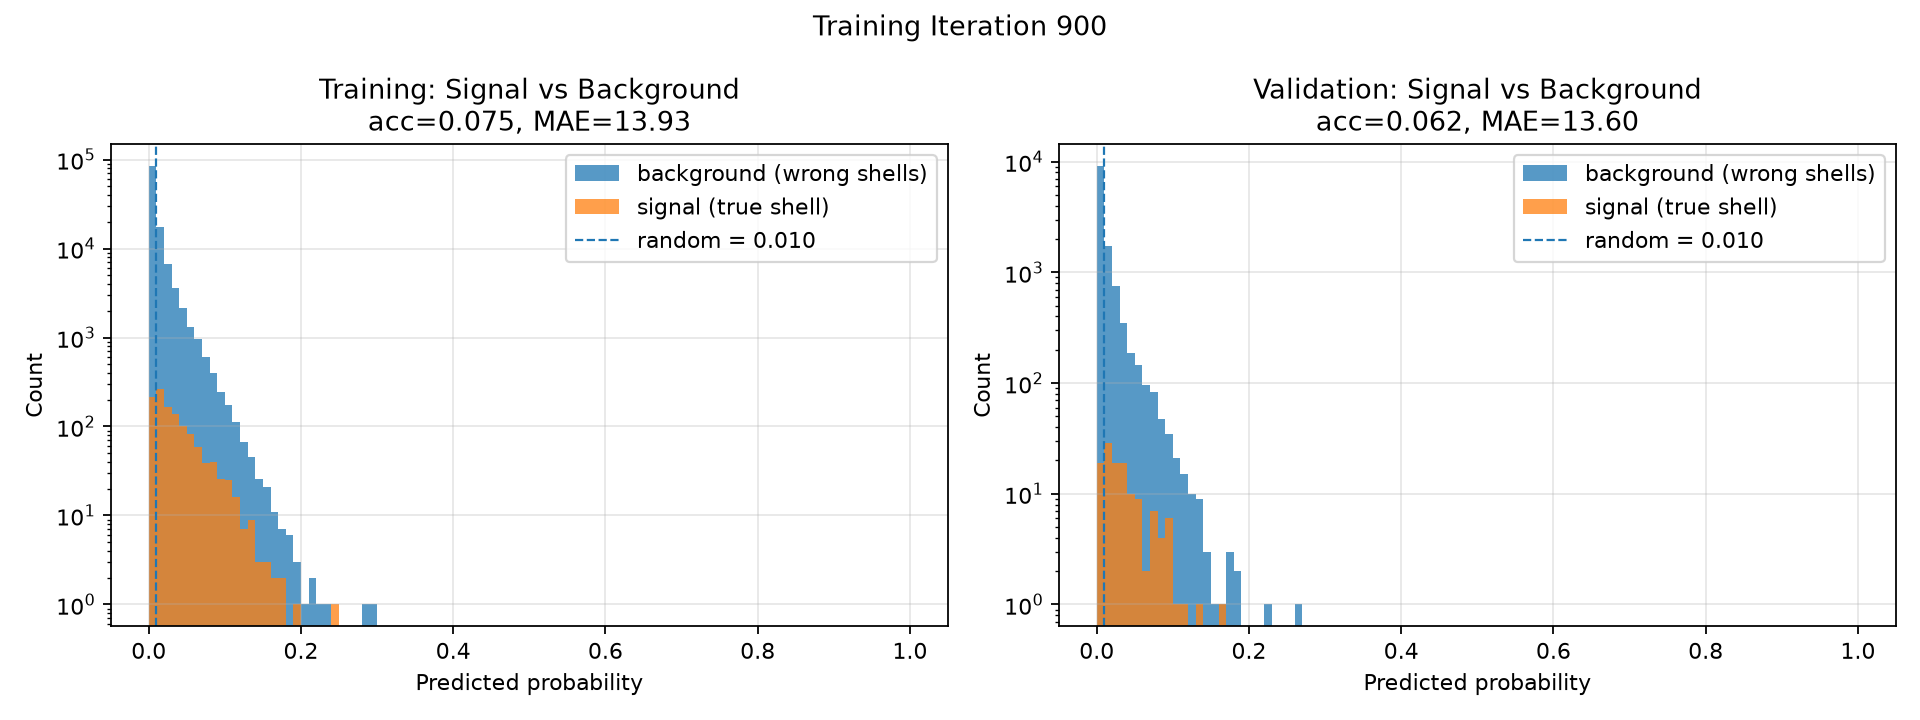

Epoch 11/15:   0%|          | 0/100 [00:00<?, ?Batch/s]

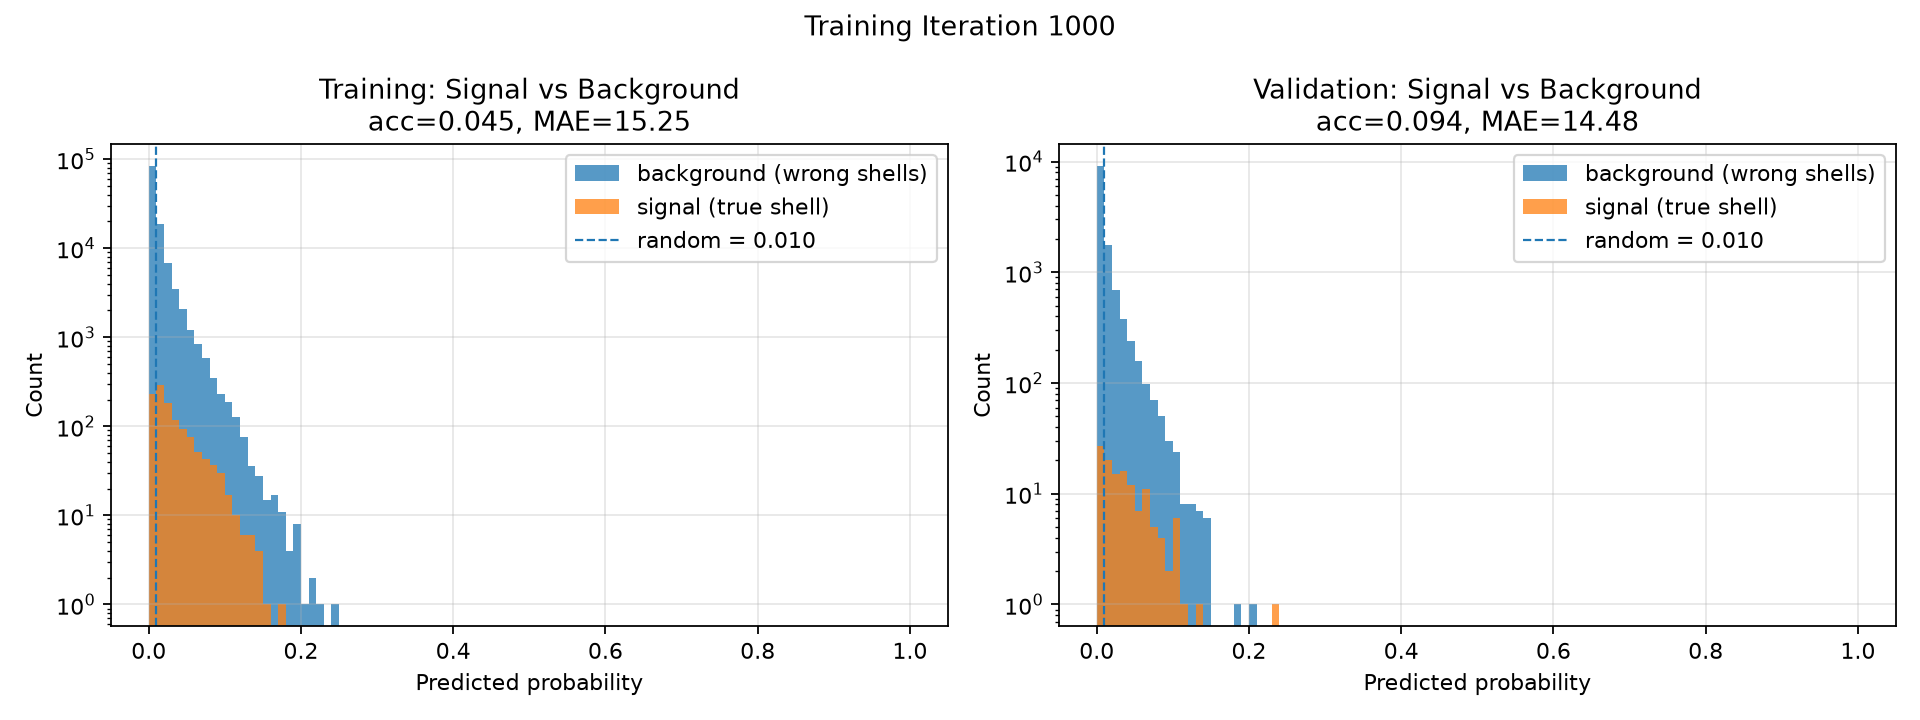

Epoch 12/15:   0%|          | 0/100 [00:00<?, ?Batch/s]

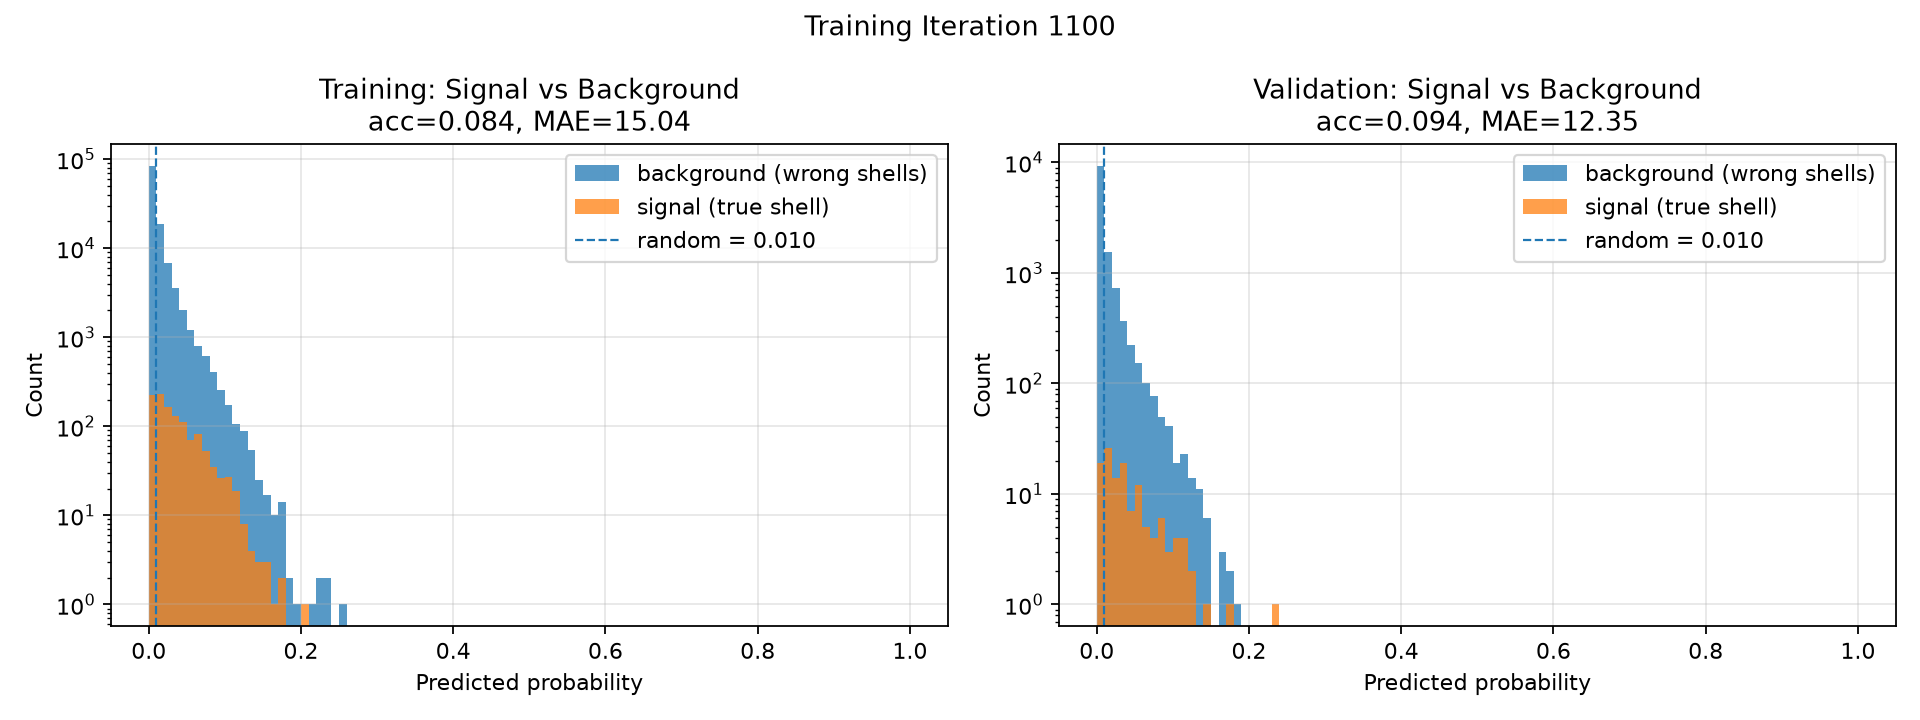

Epoch 13/15:   0%|          | 0/100 [00:00<?, ?Batch/s]

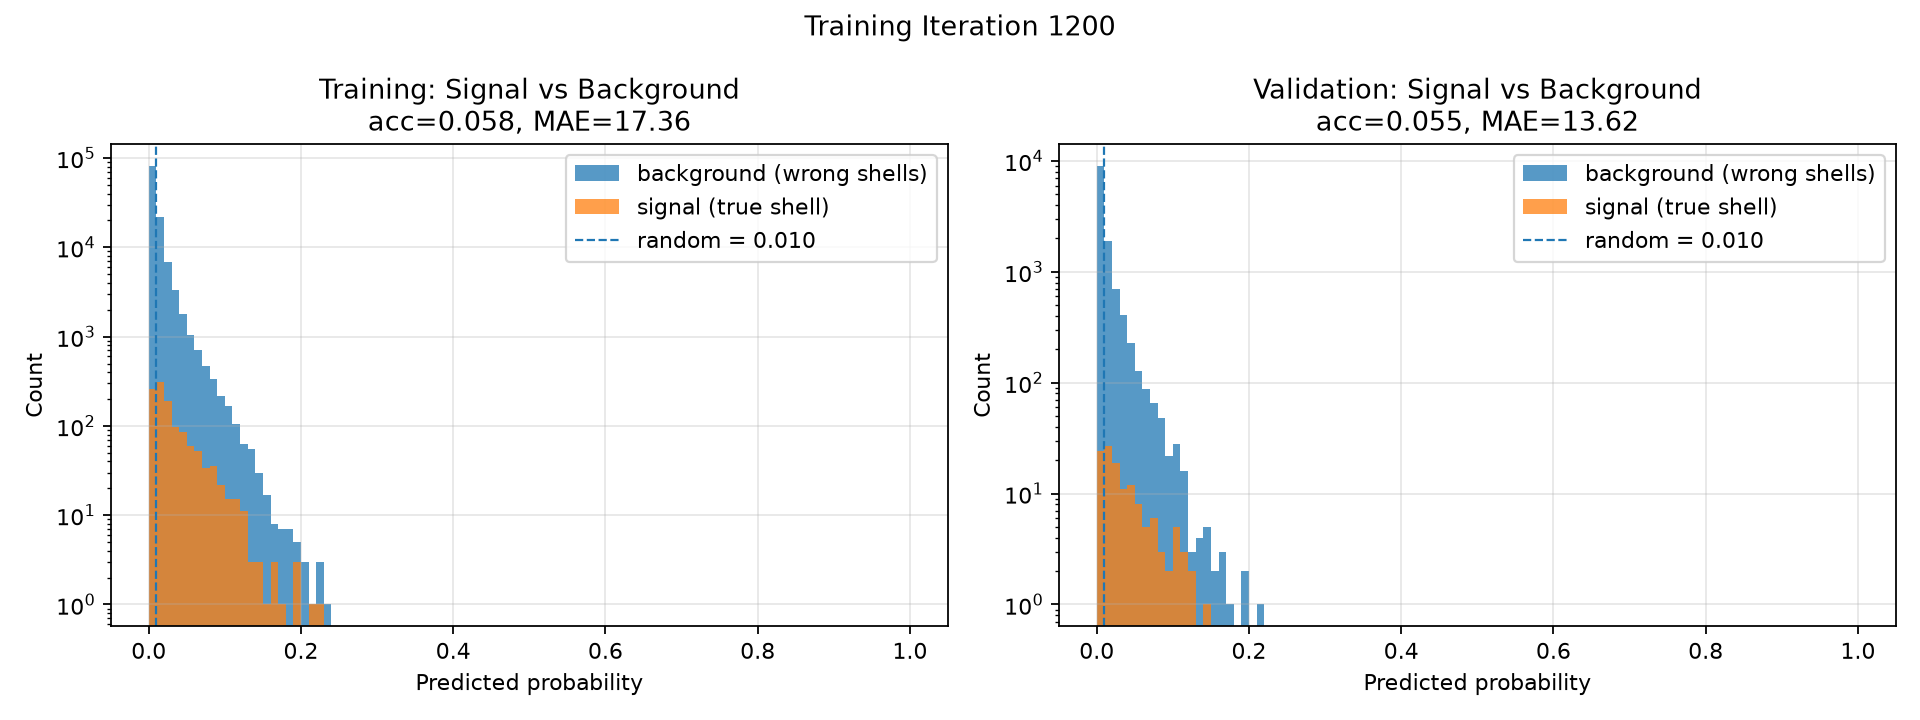

Epoch 14/15:   0%|          | 0/100 [00:00<?, ?Batch/s]

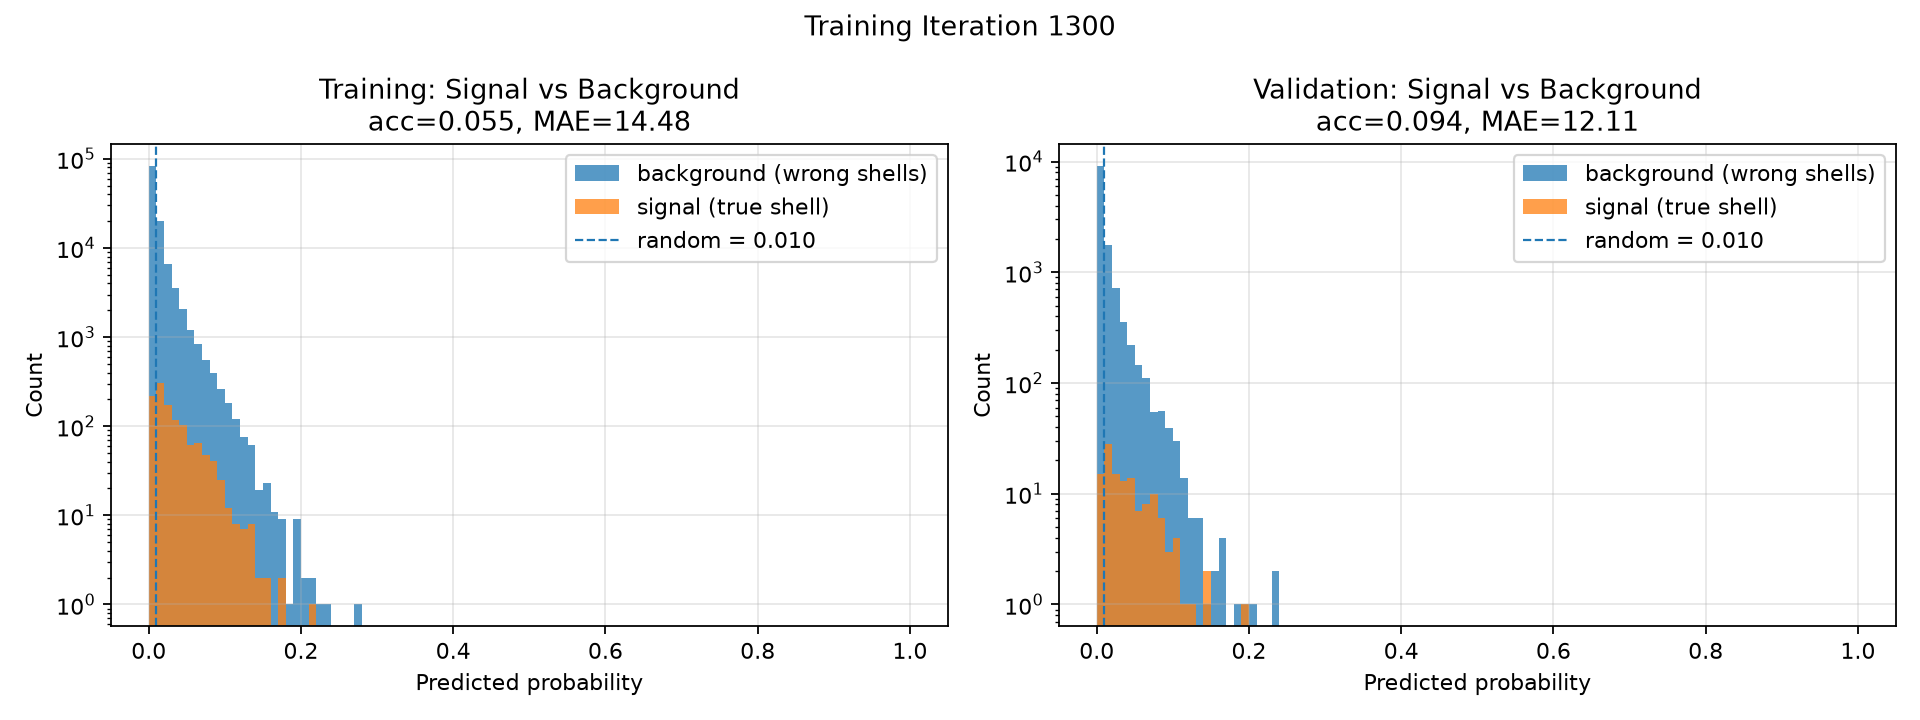

Epoch 15/15:   0%|          | 0/100 [00:00<?, ?Batch/s]

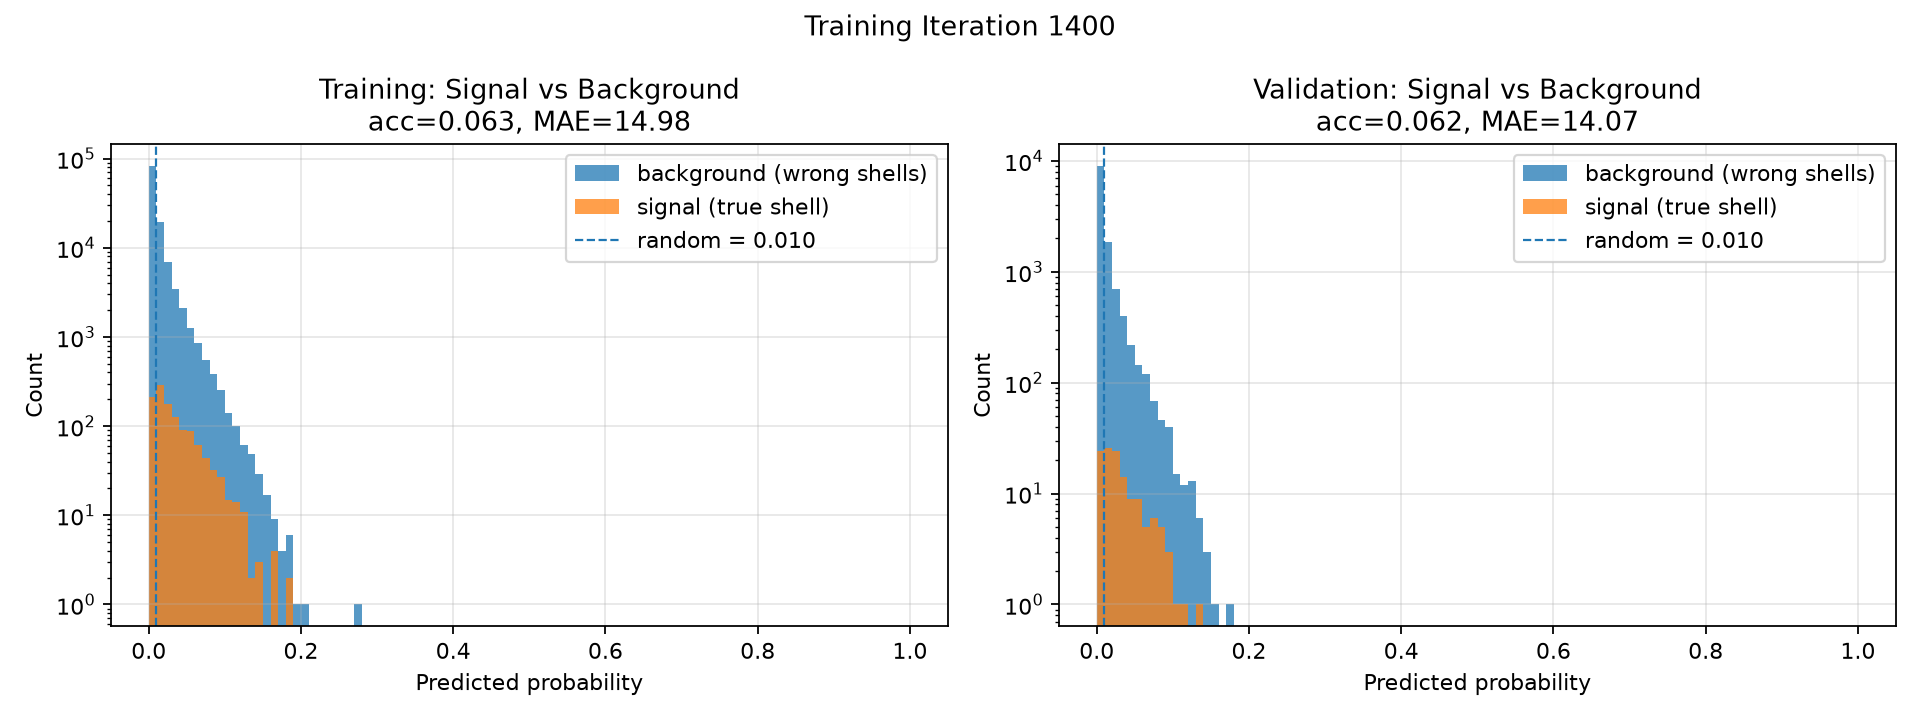

CPU times: user 6min 55s, sys: 4.19 s, total: 6min 59s
Wall time: 2min 8s


TrainResult(model_path=PosixPath('../outputs/cnp/cnp_shell_v1_model.pth'), history_csv=PosixPath('../outputs/cnp/cnp_shell_v1_history.csv'), history_plot=PosixPath('../outputs/cnp/cnp_shell_v1_training_curve.png'), monitor_plot=PosixPath('../outputs/cnp/cnp_shell_v1_class_monitor_latest.png'))

In [3]:
%%time
train_result = shells.run_shell_cnp_training(SHELL_CONFIG, CNP_CONFIG)
train_result

## Predict CNP

In [4]:
%%time
train_prediction = shells.run_shell_cnp_prediction(SHELL_CONFIG, CNP_CONFIG, split="training", model_path=train_result.model_path)
print(train_prediction)
validation_prediction = shells.run_shell_cnp_prediction(SHELL_CONFIG, CNP_CONFIG, split="validation", model_path=train_result.model_path)
print(validation_prediction)

Predicting training:   0%|          | 0/252 [00:00<?, ?file/s]


Prediction split:  training
Predicted events:  968,975
Prediction groups:  205
Saved predictions: ../outputs/cnp/cnp_shell_v1_output.csv
ShellPredictionResults(prediction_path=PosixPath('../outputs/cnp/cnp_shell_v1_output.csv'), n_events=968975, n_groups=205)


Predicting validation:   0%|          | 0/38 [00:00<?, ?file/s]


Prediction split:  validation
Predicted events:  385,954
Prediction groups:  5
Saved predictions: ../outputs/cnp/cnp_shell_v1_output_validation.csv
ShellPredictionResults(prediction_path=PosixPath('../outputs/cnp/cnp_shell_v1_output_validation.csv'), n_events=385954, n_groups=5)
CPU times: user 1h 16min 1s, sys: 11 s, total: 1h 16min 12s
Wall time: 7min 52s


## Visualize CNP Predictions

Predicted minus truth total: -0.00


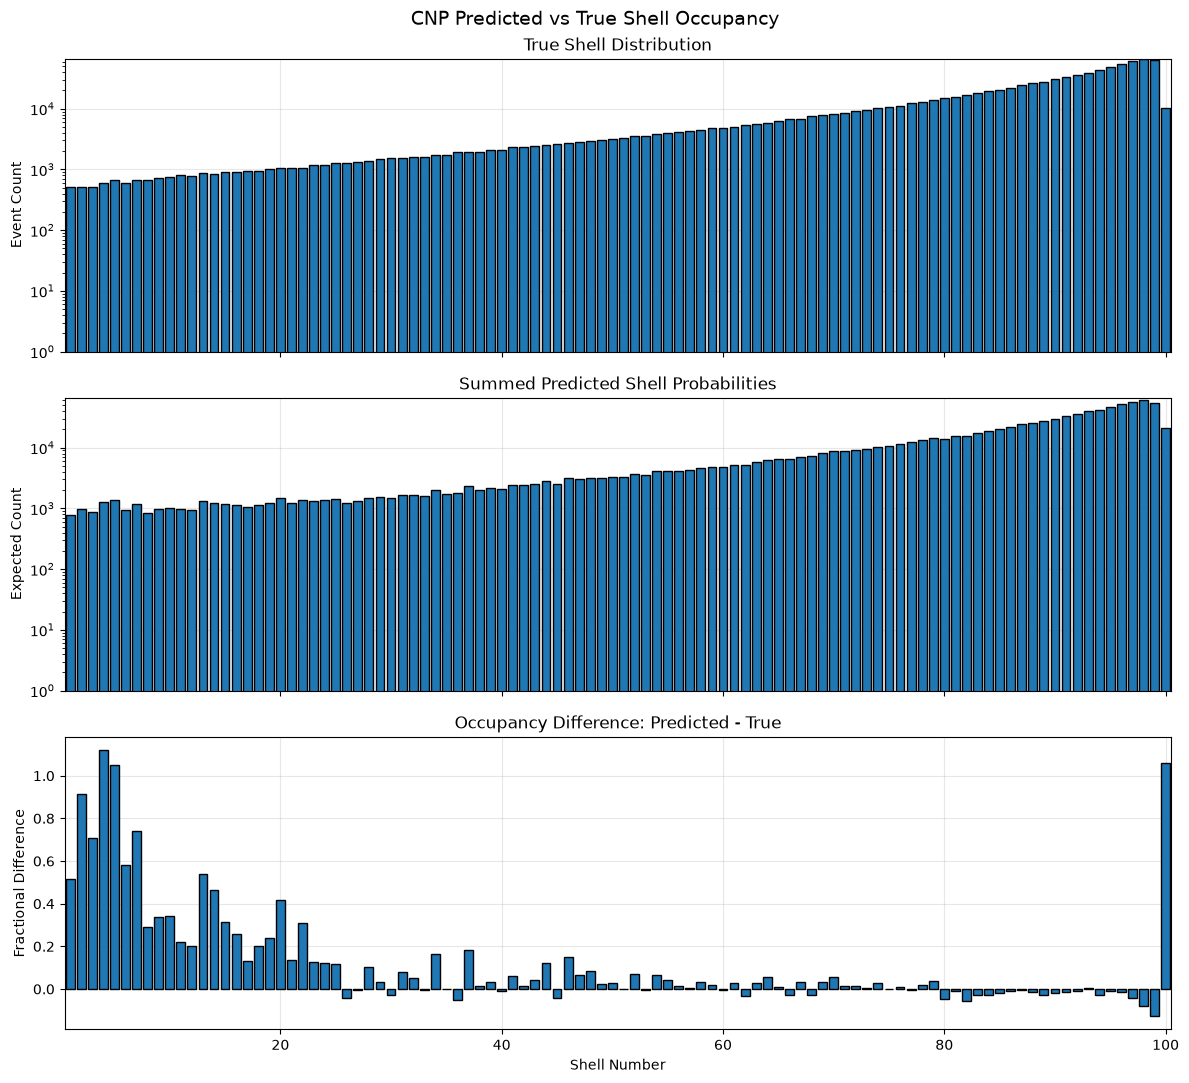

Predicted minus truth total: 0.00


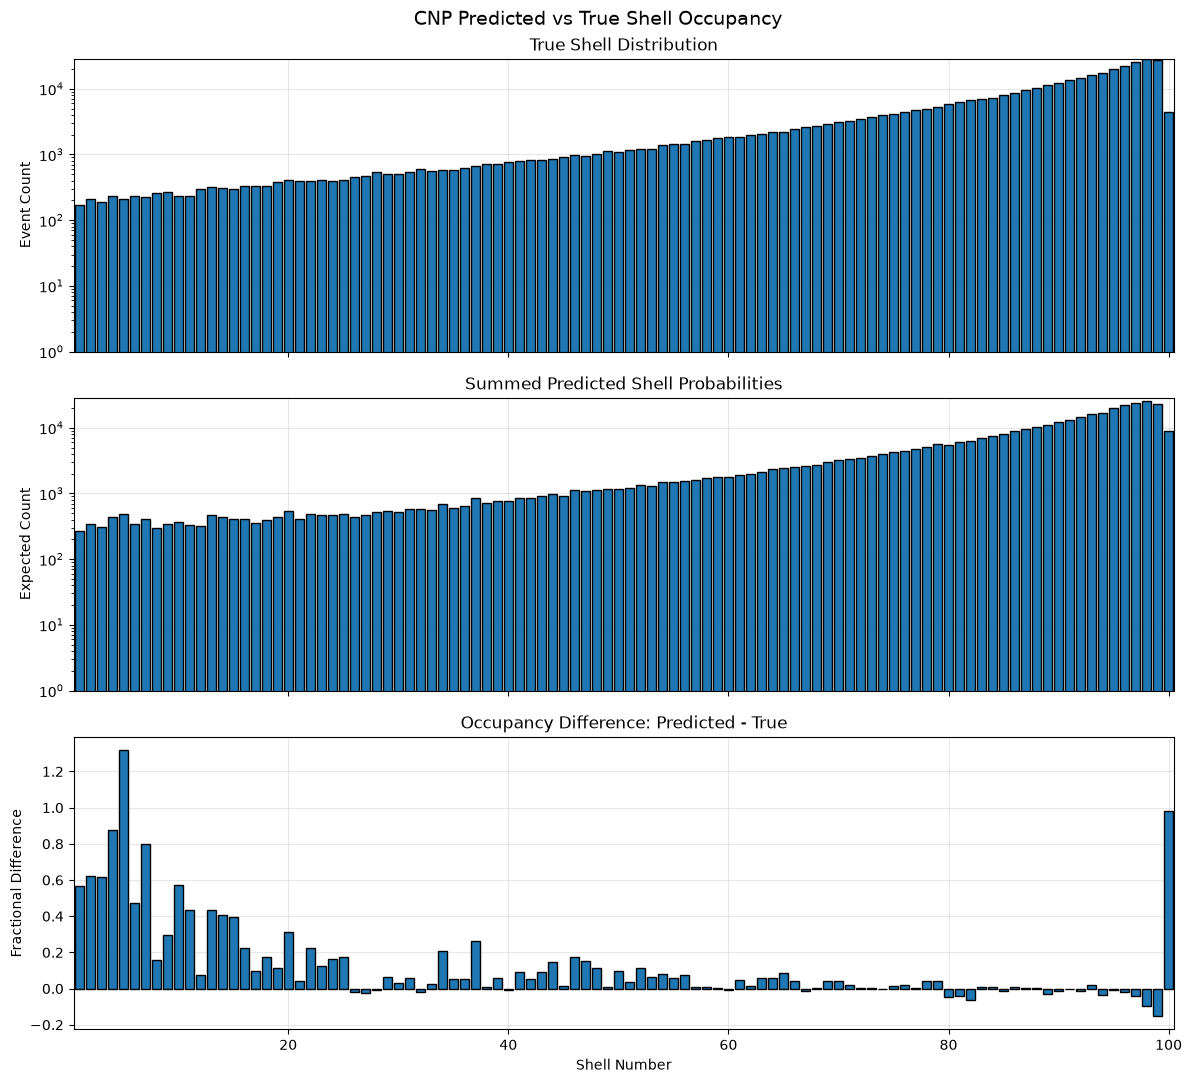

CPU times: user 635 ms, sys: 36 ms, total: 671 ms
Wall time: 667 ms


In [5]:
%%time
train_fig, train_axes = visualize.plot_cnp_pred_shell_occupancy(train_prediction.prediction_path)
plt.show(train_fig)
validation_fig, validation_axes = visualize.plot_cnp_pred_shell_occupancy(validation_prediction.prediction_path)
plt.show(validation_fig)

## Inspect CNP Matrics

In [6]:
%%time
train_pred_df = pd.read_csv(train_prediction.prediction_path)
validation_pred_df = pd.read_csv(validation_prediction.prediction_path)

display(train_pred_df.head())
display(validation_pred_df.head())

print(f"Model:                 {train_result.model_path}")
print(f"Training history:      {train_result.history_csv}")
print(f"Training prediction:   {train_prediction.prediction_path}")
print(f"Validation prediction: {validation_prediction.prediction_path}")

,iteration,split_name,fidelity,n_samples,detector_R,detector_Z,detector_z_center,shell_index,y_cnp,y_cnp_err,y_raw,source_file
0,0,training,0,1313,104.0,1265.0,1265.0,1,0.004530,0.001245,0.009139,aggregated_event_shell_predictions
1,0,training,0,1313,104.0,1265.0,1265.0,2,0.005536,0.001326,0.006855,aggregated_event_shell_predictions
2,0,training,0,1313,104.0,1265.0,1265.0,3,0.004671,0.001168,0.003808,aggregated_event_shell_predictions
3,0,training,0,1313,104.0,1265.0,1265.0,4,0.006163,0.001245,0.005331,aggregated_event_shell_predictions
4,0,training,0,1313,104.0,1265.0,1265.0,5,0.005904,0.001376,0.004570,aggregated_event_shell_predictions


,iteration,split_name,fidelity,n_samples,detector_R,detector_Z,detector_z_center,shell_index,y_cnp,y_cnp_err,y_raw,source_file
0,0,validation,1,59342,194.0,379.0,379.0,1,0.003700,0.000847,0.002780,aggregated_event_shell_predictions
1,0,validation,1,59342,194.0,379.0,379.0,2,0.004667,0.000951,0.003286,aggregated_event_shell_predictions
2,0,validation,1,59342,194.0,379.0,379.0,3,0.004004,0.000793,0.003084,aggregated_event_shell_predictions
3,0,validation,1,59342,194.0,379.0,379.0,4,0.005552,0.000943,0.003573,aggregated_event_shell_predictions
4,0,validation,1,59342,194.0,379.0,379.0,5,0.005235,0.000995,0.003320,aggregated_event_shell_predictions


Model:                 ../outputs/cnp/cnp_shell_v1_model.pth
Training history:      ../outputs/cnp/cnp_shell_v1_history.csv
Training prediction:   ../outputs/cnp/cnp_shell_v1_output.csv
Validation prediction: ../outputs/cnp/cnp_shell_v1_output_validation.csv
CPU times: user 19.3 ms, sys: 0 ns, total: 19.3 ms
Wall time: 18.4 ms


## Train and Validate MFGP

In [7]:
%%time
mfgp_train_result = shells.run_shell_mfgp_training(
    train_prediction.prediction_path,
    MFGP_CONFIG,
)

mfgp_validation_result = shells.run_shell_mfgp_prediction(
    validation_prediction.prediction_path,
    MFGP_CONFIG,
    model_path=mfgp_train_result.model_path,
)

=== MF-GP training: mfgp_v1 ===
[data] LF points=200 | HF points=5 | input_dim=2
[target] linear | alpha_lf=1.05148e-05 | alpha_hf=1e-10
[fit] Training LF GP...
[fit] Estimated rho=0.832009
[fit] Training HF discrepancy GP...
[fit] GP training complete.


MF-GP training prediction:   0%|          | 0/1 [00:00<?, ?chunk/s]

[saved] model: ../outputs/mfgp/mfgp_mfgp_v1_model.joblib
[saved] training predictions: ../outputs/mfgp/mfgp_mfgp_v1_training_predictions.csv
[saved] metrics: ../outputs/mfgp/mfgp_mfgp_v1_metrics.json
[done] RMSE=2.00616e-11 | MAE=1.48124e-11 | 1σ coverage=1.000


MF-GP prediction:   0%|          | 0/1 [00:00<?, ?chunk/s]

CPU times: user 1min 6s, sys: 3.72 ms, total: 1min 6s
Wall time: 2.95 s


## Visualize MFGP Predictions

MF-GP prediction:   0%|          | 0/1 [00:00<?, ?chunk/s]

PosixPath('../outputs/mfgp/mfgp_mean_uncertainty.png')

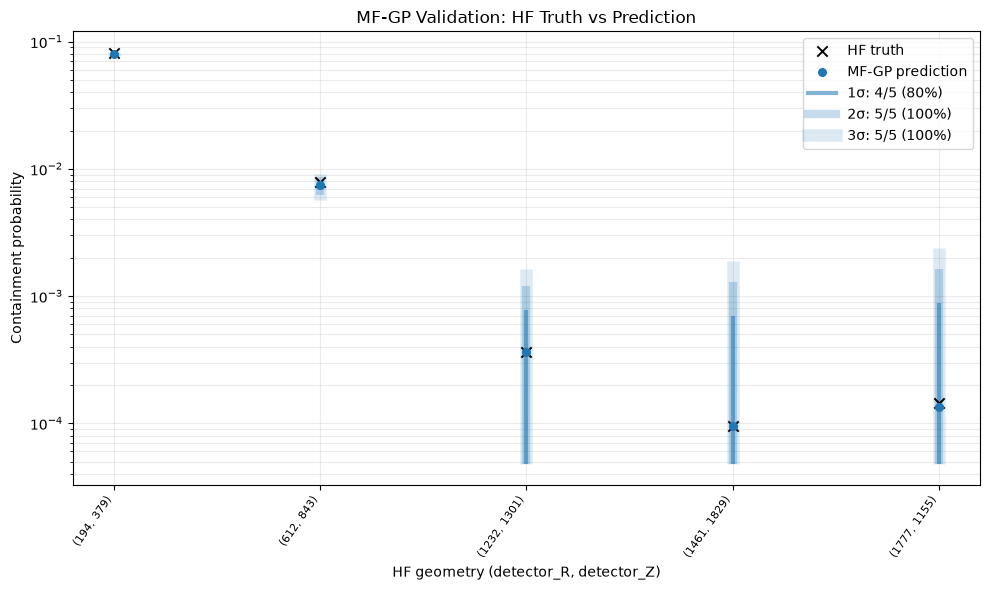

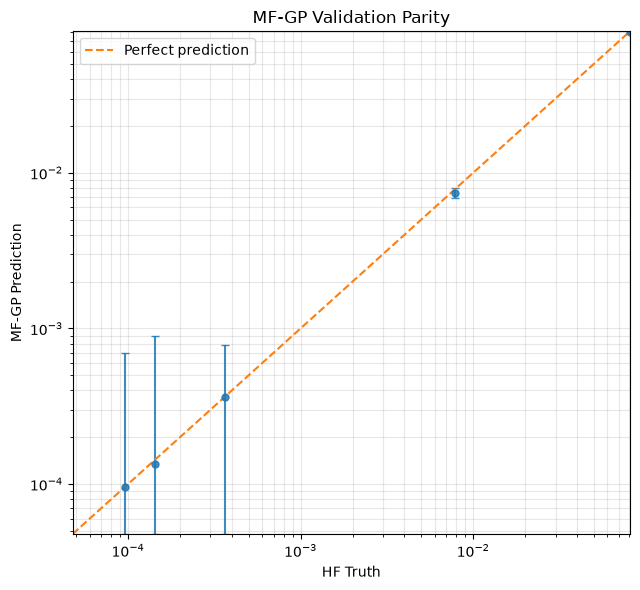

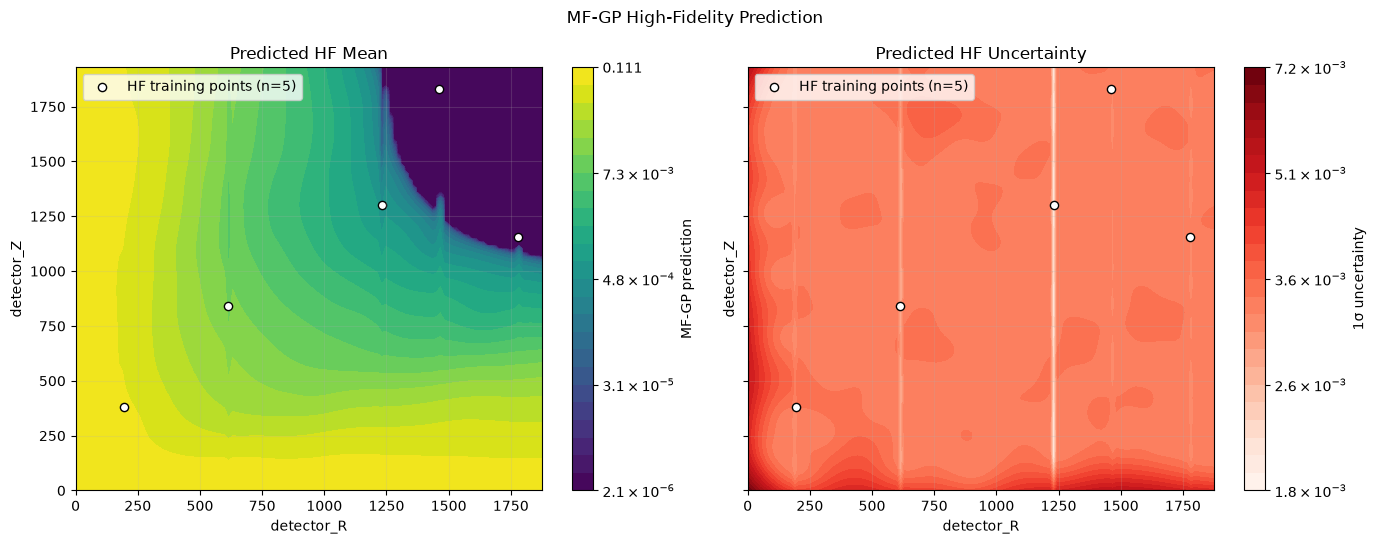

In [8]:
plot_dir = mfgp_train_result.model_path.parent

# Validation and Parity Plots
visualize.plot_mfgp_validation_points(
    mfgp_validation_result,
    outpath=plot_dir / "validation_points.png",
)
visualize.plot_mfgp_validation_parity(
    mfgp_validation_result,
    outpath=plot_dir / "validation_parity.png",
)

# Mean/Uncertainty Plot
hf_train = pd.read_csv(mfgp_train_result.training_prediction_csv)

r_max = hf_train["detector_R"].max() + 100
z_max = hf_train["detector_Z"].max() + 100
r = np.linspace(0, r_max, 120)
z = np.linspace(0, z_max, 120)

R, Z = np.meshgrid(r, z)
grid = pd.DataFrame({
    "detector_R": R.ravel(),
    "detector_Z": Z.ravel(),
})
grid_result = mfgp.run_mfgp_prediction(
    MFGP_CONFIG,
    model_path=mfgp_train_result.model_path,
    x=grid,
    output_path=mfgp_train_result.model_path.with_name("mfgp_grid_predictions.csv"),
)
fig, axes = visualize.plot_mfgp_mean_uncertainty(
    grid_result,
    hf_points=hf_train,
    outpath=mfgp_train_result.model_path.with_name("mfgp_mean_uncertainty.png"),
)

display(mfgp_train_result.model_path.with_name("mfgp_mean_uncertainty.png"))

## Inspect MFGP Metrics

In [9]:
metrics = mfgp_validation_result.metrics

pd.DataFrame({
    "metric": ["RMSE", "MAE", "R²", "Bias", "Pearson r", "Pull mean", "Pull std",
               "1σ coverage", "2σ coverage", "3σ coverage"],
    "value": [metrics["rmse"], metrics["mae"], metrics["r2"], metrics["bias"],
              metrics["pearson_r"], metrics["pull_mean"], metrics["pull_std"],
              metrics["coverage_1sigma"], metrics["coverage_2sigma"],
              metrics["coverage_3sigma"]],
})

,metric,value
0,RMSE,0.000480
1,MAE,0.000283
2,R²,0.999771
3,Bias,-0.000283
4,Pearson r,0.999992
5,Pull mean,-0.353742
6,Pull std,0.493619
7,1σ coverage,0.800000
8,2σ coverage,1.000000
9,3σ coverage,1.000000
